## Summary of key insights

- Most features are categorical (all but price and sale date), many of them take a huge number of different values, many values appearing only once, which will make prediction difficult without some pooling

- The price distribution is very right skewed, so much so that I had to cap the price at say 30k to make graphics legible.

- Almost all sales were done after 1985. A very strong inflation is visible over time since 1985, stronger than general consumer index inflation. Perhaps a feature "inflation corrected price" is needed.

- Cellos are the most valued, followed by violins and viols and bows. Several instrument types are very rare.

- The 40 distinct auction_houses achieve remarkably different distribution prices. So do the 30 most frequent makers. French makers and auction_houses are particulary represented among the most expensive sales. A nationality feature could be interesting, though there is already a city (of sale, and of maker) feature that might do the trick.

- In general, the more ancient the instrument, the more valuable. Yet 1500 makers lack the date, representing 6k sales, which is a significant caveat. Ideally, we could write some script to fetch their date from some other database on internet.

## Importation of packages and data frames

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
sales=pd.read_csv("cozio_sales_ALL.csv")

In [45]:
maker_profiles=pd.read_csv("maker_profiles_ALL.csv")

## Creation of a feature 'last_name'

In [7]:
def last_name(name):
    return name.split(",")[0]

In [9]:
sales["maker_last_name"]=sales["maker_name"].apply(last_name)

In [ ]:
sales["maker_last_name"].value_counts()
#Hill & Sons is not really a maker's last name, many makers bearing different last names worked for it

maker_last_name
Hill & Sons    3268
Sartory        1326
Bazin          1136
Tubbs          1022
Morizot         993
               ... 
Wurmer            1
Yakoub            1
Yarrington        1
Zanier            1
Zanrè             1
Name: count, Length: 2549, dtype: int64

In [ ]:
sum(sales["maker_last_name"].value_counts()>1)
#1811 last names occur more than once in sales

1811

In [ ]:
sum(sales["maker_last_name"].value_counts()>2)
#1479 last names occur more than twice in sales

1479

In [ ]:
sum(sales["maker_last_name"].value_counts()>10)
#721 last names occur more than ten times in sales

721

In [ ]:
i=0
while (sales["maker_last_name"].value_counts().cumsum()<30000).iloc[i]:
    i+=1
i
#the 84 most popular last names represent over 30k sales (hence over the half of the total)

84

In [44]:
sales["maker_name"].value_counts()

maker_name
Hill & Sons, W. E. Firm          3268
Sartory, Eugène Nicolas          1326
Tubbs, James                      936
Nürnberger, Albert                723
Thibouville-Lamy, Jérôme Firm     689
                                 ... 
Zanti, Alessandro                   1
Zapelli, Francesco                  1
Zapf, Walter                        1
Zeswitz, William H.                 1
Zucker, Frantisek                   1
Name: count, Length: 3649, dtype: int64

In [46]:
maker_profiles["maker_last_name"]=maker_profiles["maker_name"].apply(last_name)

In [ ]:
maker_profiles["maker_last_name"].value_counts()
#17 different makers were called Gagliano

maker_last_name
Gagliano        17
Hornsteiner     16
Schmidt         15
Pfretzschner    15
Klotz           14
                ..
Zari             1
Allan            1
Allard           1
Alleaume         1
Allen            1
Name: count, Length: 3397, dtype: int64

In [ ]:
sum(maker_profiles["maker_last_name"].value_counts()>1)
#684 last names had more than one person bearing that name

684

In [ ]:
sum(maker_profiles["maker_last_name"].value_counts()>10)
#10 last names had at least 10 makers with that last name

10

## The feature 'year' (of sale)

In [69]:
def year(date):
    return int(date.split(", ")[-1])

In [74]:
sales['year']=sales.sale_date.apply(year)

<Axes: >

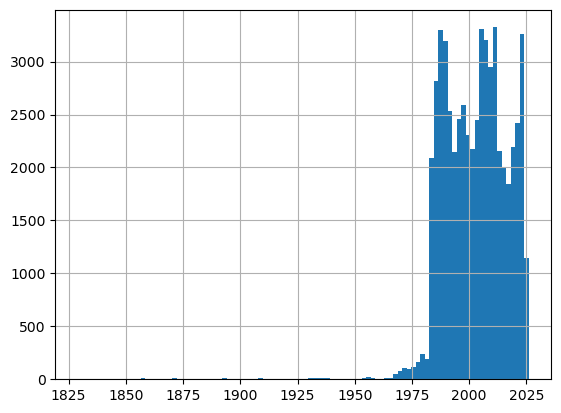

In [85]:
sales.year.hist(bins=100)
#sales year run from 1825 to 2025 but almost all sales are post 1980, perhaps we should stick to that

In [83]:
(sales.year>1980).mean()
#98% of sales are post 1980

np.float64(0.9807937868425195)

In [86]:
(sales.year>1985).mean()
#only 91% of sales are post 1985, so keep until 1980

np.float64(0.9152337805454005)

In [102]:
mask_recent=sales.year>1985
sales_recent=sales[mask_recent]

In [ ]:
sales[mask_recent]['usd'].describe()

count    5.232000e+04
mean     1.594871e+04
std      1.287757e+05
min      2.400000e+01
25%      1.718000e+03
50%      3.900000e+03
75%      9.915750e+03
max      1.582128e+07
Name: usd, dtype: float64

the mean usd price of the sales of the past 45 years was 16k, but the median was 3.9k!A few extreme prices (up to 16M!) drove the mean absurdly high. 75% sales were under 10k.

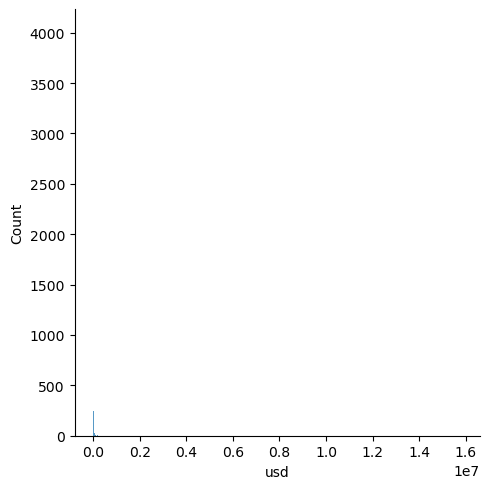

In [107]:
sns.displot(data=sales[mask_recent],x="usd")

In [385]:
(sales_recent['usd']<30000).mean()
#90% sales were under 30k, we might want to focus on these moderate prices. The distribution plot above is incredibly skewed
#otherwise.

np.float64(0.9075167708273608)

In [109]:
mask_moder=sales_recent['usd']<30000
sales_moder=sales_recent[mask_moder]

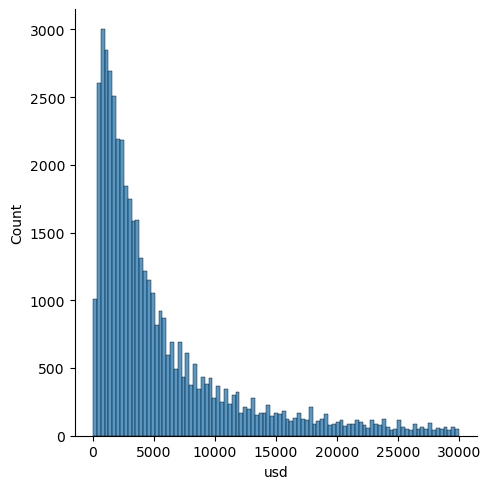

In [113]:
sns.displot(data=sales_moder,x="usd")
#still quite right-skewed, but at least legible

## The 'type' feature

In [118]:
sales_moder.type.value_counts()

type
Violin           19937
Violin Bow       16448
Cello Bow         3997
Viola             2518
Viola Bow         2286
Cello             1810
Small Violin       235
Bass Bow           172
Bass                56
Treble Viol         11
Tenor Viol           6
Bass Viol            3
Miscellaneous        3
Viola d'Amore        2
Name: count, dtype: int64

In [ ]:
sales.type.value_counts()
#similar distrbution of types, whether we include the very old or very expensive objects or not. 
#Cellos have been particularly badly maked out though. Some types are very rare such as "small violin", "bass bow" etc.

type
Violin           25928
Violin Bow       18041
Cello Bow         4413
Viola             2963
Cello             2728
Viola Bow         2474
Small Violin       300
Bass Bow           197
Bass                76
Tenor Viol          16
Bass Viol           13
Treble Viol         12
Miscellaneous        5
Viola d'Amore        3
Name: count, dtype: int64

<Axes: xlabel='usd'>

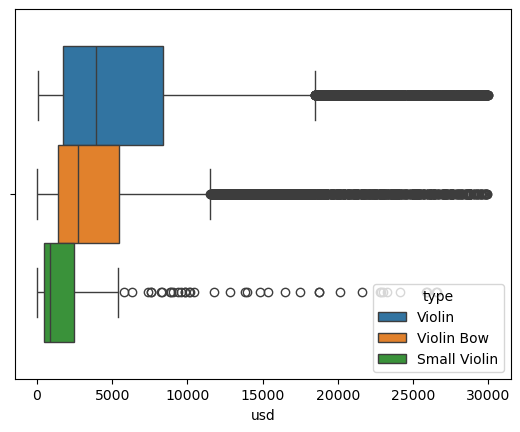

In [122]:
sns.boxplot(data=data,x='usd',hue='type')

It looks like small violin has a different price distribution than violin. Interestingly, violins bows are rather cheaper than violins, but still more expansive than violin bows. All these types seem frankly right skewed.

<Axes: xlabel='usd'>

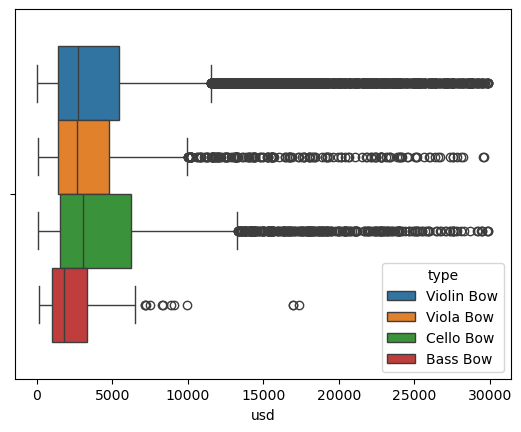

In [126]:
data_bow=sales_moder[sales_moder.type.str.contains('Bow')]
sns.boxplot(data=data_bow,x='usd',hue='type')

Looks like the four types of bows have similar price distributions. Bass bows tend to be cheaper but there are much fewer occurrences of them.

## Evolution of prices year after year

<Axes: xlabel='usd'>

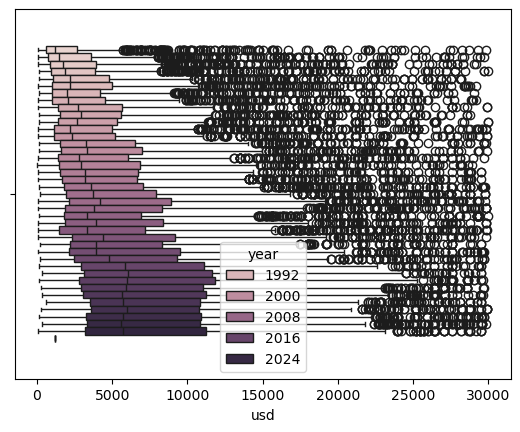

In [130]:
sns.boxplot(data=sales_moder,x='usd',hue='year')

We do observe some inflation across the years.

In [132]:
sales_moder[['usd','year']].groupby('year').describe()

usd                                                               \
       count         mean          std     min      25%     50%       75%   
year                                                                        
1986  1332.0  2572.433183  4020.799651    50.0   587.50  1196.0   2627.00   
1987  1541.0  3183.588579  4423.103674    90.0   744.00  1474.0   3601.00   
1988  1617.0  3489.536178  4634.134320    84.0   889.00  1750.0   3932.00   
1989  1685.0  3414.460534  4425.765285   116.0   928.00  1839.0   3850.00   
1990  1365.0  4007.942125  4944.715333    99.0  1033.00  2165.0   4764.00   
1991  1258.0  4206.215421  5212.030108    33.0  1020.25  2215.0   4950.00   
1992  1151.0  3651.039965  4584.199413   125.0   984.50  1970.0   4199.00   
1993  1033.0  4154.128751  5334.438111    94.0  1018.00  2076.0   4515.00   
1994   983.0  4577.164802  5273.143065    75.0  1416.50  2735.0   5630.00   
1995  1154.0  4691.906412  4974.981721   129.0  1544.00  2908.0   5614.00   
1996  1159.0  4506.714409  5166.114527   127.0  1380.00  2649.0   5301.00   
1997  1286.0  4367.793157  5546.319687    59.0  1158.00  2193.0   4977.00   
1998  1142.0  4430.183012  5494.124162    47.0  1150.00  2307.0   5187.25   
1999   975.0  5300.313846  5743.288993   129.0  1495.00  3260.0   6529.00   
2000  1158.0  5418.135579  5700.449923   115.0  1596.75  3300.0   6949.00   
2001  1119.0  4965.518320  5577.171780    76.0  1415.00  2813.0   6058.00   
2002   884.0  5193.199095  5678.805326    24.0  1490.00  2954.5   6821.25   
2003   998.0  5242.920842  5604.400555    72.0  1499.25  3215.5   6736.00   
2004  1268.0  5243.422713  5630.295513    93.0  1682.75  3163.0   6619.00   
2005  1785.0  5696.418487  5794.467896   119.0  1763.00  3597.0   7050.00   
2006  1217.0  6122.452753  6302.940572   176.0  1922.00  3738.0   7939.00   
2007  1257.0  6634.752586  6570.706886    69.0  2115.00  4174.0   8932.00   
2008  1560.0  6164.215385  6209.718601    48.0  1868.50  3802.0   8287.00   
2009  1286.0  5585.769051  6001.269770   107.0  1771.25  3300.0   6920.00   
2010  1335.0  6335.371536  6335.690866    56.0  1865.50  3900.0   8400.00   
2011  1955.0  5449.033248  5932.395837    66.0  1458.00  3300.0   7200.00   
2012  1009.0  6934.964321  6616.664657    84.0  2309.00  4372.0   9188.00   
2013   920.0  6246.780435  6132.004077   180.0  2160.00  3900.0   8288.25   
2014   952.0  6873.935924  6921.434873    75.0  2124.00  3932.0   9522.00   
2015  1004.0  7101.015936  6628.233830   184.0  2460.00  4800.0   9280.25   
2016   716.0  7962.856145  6481.187619   156.0  2929.00  5858.0  11105.00   
2017   763.0  8444.604194  6903.075063   330.0  3088.50  6044.0  11646.00   
2018   748.0  8471.957219  7413.160926   118.0  2760.00  5950.0  11800.00   
2019   922.0  8174.611714  6918.720551   248.0  2950.00  5900.0  11006.00   
2020  1003.0  8017.463609  6676.900918   309.0  3059.50  5618.0  11235.00   
2021   962.0  8182.436590  6643.756020   595.0  3491.00  5700.0  10800.00   
2022  1133.0  8092.293910  6289.355528   295.0  3600.00  5988.0  10743.00   
2023  1451.0  8067.297726  6559.779859   162.0  3273.00  5730.0  10908.50   
2024  1390.0  8071.331655  6679.348046   325.0  3296.25  5593.0  10800.00   
2025  1007.0  8213.102284  6688.684050    89.0  3186.00  5709.0  11212.00   
2026     1.0  1180.000000          NaN  1180.0  1180.00  1180.0   1180.00   

               
          max  
year           
1986  29814.0  
1987  29704.0  
1988  29167.0  
1989  29956.0  
1990  28172.0  
1991  29213.0  
1992  29040.0  
1993  29188.0  
1994  29900.0  
1995  28750.0  
1996  29999.0  
1997  29860.0  
1998  29900.0  
1999  29865.0  
2000  29900.0  
2001  29682.0  
2002  28913.0  
2003  29499.0  
2004  29505.0  
2005  29784.0  
2006  29793.0  
2007  29800.0  
2008  29861.0  
2009  29987.0  
2010  29840.0  
2011  29912.0  
2012  29865.0  
2013  29520.0  
2014  29732.0  
2015  29699.0  
2016  29500.0  
2017  29500.0  
2018  29619.0  
2019  29715.0  
2020  29648.0  
2021  29525.

There was roughly 1k sales per year. There is no clear trend in the number of sales per year since 1985. The median price rose from 1,2k to 5,7k from 1985 to 2025, a ratio close to 5. This is a significantly faster pace than general inflation of prices in USD - the ratio is about 3.

Perhaps year is not the best period to look at. I'll include the decade (1986-95, 1996-2005) for simplicity. I'll remove the single entry of the year 2026.

In [143]:
def decade(year):
    a=(year-1986) // 10
    return f"{1986+10*a}-{1986+10*a+9}"

In [144]:
sales_moder=sales_moder[sales_moder["year"]<2026]
sales_moder["decade"]=sales_moder["year"].apply(decade)

In [ ]:
sales_recent[['usd','decade']].groupby('decade').describe()

usd                                                           \
             count         mean          std   min     25%     50%      75%   
decade                                                                        
1986-1995  13119.0  3727.263663  4790.727161  33.0   936.0  1949.0   4331.0   
1996-2005  11774.0  5056.730508  5618.792519  24.0  1452.0  2943.0   6325.0   
2006-2015  12495.0  6252.003922  6346.136368  48.0  1894.0  3809.0   8260.0   
2016-2025  10095.0  8152.118574  6698.623464  89.0  3245.0  5852.0  11057.5   

                    
               max  
decade              
1986-1995  29956.0  
1996-2005  29999.0  
2006-2015  29987.0  
2016-2025  29942.0

There the general increase of price is visible, in every metric (oviously not max since I capped at 30k)

## 'Rough type' feature and its impact

In [169]:
def rough_type(type):
    if 'Bow' in type:
        return 'Bow'
    elif type in type_list[-8:]:
        return 'Rare'
    else:
        return type

In [170]:
type_list=sales_moder['type'].unique()

In [171]:
[rough_type(type) for type in type_list]

['Violin',
 'Bow',
 'Cello',
 'Bow',
 'Bow',
 'Viola',
 'Bow',
 'Rare',
 'Rare',
 'Rare',
 'Rare',
 'Rare',
 'Rare',
 'Rare']

In [172]:
sales_moder['rough_type']=sales_moder['type'].apply(lambda x : rough_type(x))

<Axes: xlabel='usd'>

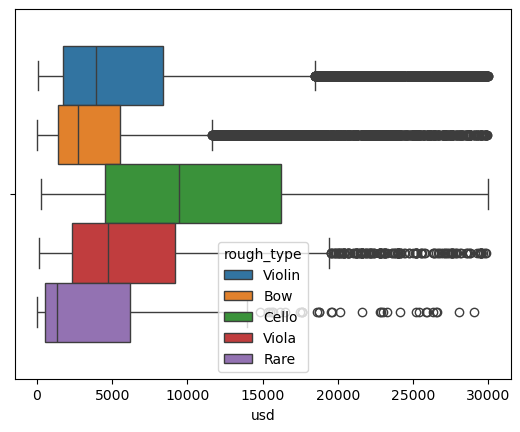

In [174]:
sns.boxplot(data=sales_moder,x='usd',hue='rough_type')

Among the major types, we immediately see that cello is the most expansive, in front of violin and viola (which display similar distributions), bows tend to be cheaper but can also reach very high values (more right skewed than instruments). Rare types are usually less valued, but again hugely right-skewed).

We include below a box-plot of the distributions of prices of rare types, but it may not be significant since 5 of the rare types are extremly rare (all but small violin and bass), with less than 11 occurrences in the moderate data base.

<Axes: xlabel='usd'>

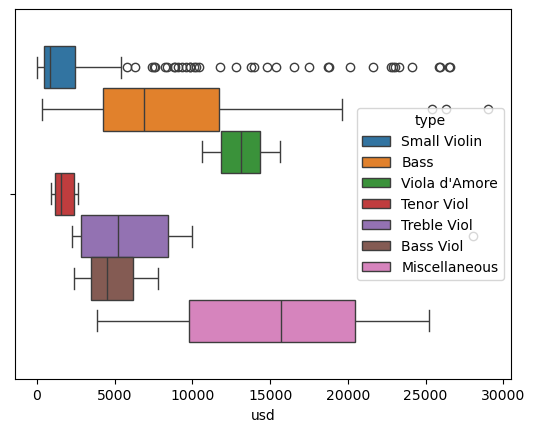

In [175]:
sns.boxplot(data=sales_moder[sales_moder['rough_type']=='Rare'],x='usd',hue='type')

## Currencies and bold_currency

In [189]:
sum(sales.eur.isna()), sum(sales.usd.isna()), sum(sales.gbp.isna())


(22368, 4, 4)

USD and GBP are almost always given. On 2/5 of the archive, the euro price is not present - this corresponds essentially to the sales before 2002, when the euro was introduced. We notice that 4 sales have no usd price, let's have a look at them.

In [191]:
sales[sales.usd.isna()]

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency,maker_last_name,year
11449,1338,"Cuypers, Johannes Theodorus",Violin,The Hague,Bongartz's,"Nov 20, 1989",316,NaN,NaN,NaN,NaN,Cuypers,1989
21461,1838,"Hel, Pierre Joseph",Violin Bow,Lille,Bongartz's,"Nov 18, 1985",362,NaN,NaN,NaN,NaN,Hel,1985
27415,8597,"Knorr, Albert Albrecht",Violin,Markneukirchen,Bongartz's,"May 2, 1988",151,NaN,NaN,NaN,NaN,Knorr,1988
41299,560,"Pollastri, Augusto",Violin,Bologna,Bongartz's,"Apr 27, 1987",247,NaN,NaN,NaN,NaN,Pollastri,1987


These 4 sales have actually no price whatsoever mentioned and all come from the auction_house Bongartz. A quick look at the website seems to indicate the fault comes from there and is not an artefact of scraping.

In [204]:
sales.bold_currency.value_counts()

bold_currency
gbp    31786
usd    16003
eur     5330
Name: count, dtype: int64

## auction_house feature

In [227]:
sales.auction_house.value_counts()

auction_house
Tarisio                                  12441
Sotheby's                                11038
Phillip's                                 6386
Christie's                                4875
Skinner                                   4086
Bonhams                                   3436
Bongartz's                                3282
Vichy-Enchères                            2062
Brompton's                                1705
Ingles & Hayday                           1419
Sotheby Parke Bernet                       283
Millon & Associés (Gilles Chancereul)      274
Puttick & Simpson                          208
Dorotheum                                  207
Guy Laurent                                174
Gardiner-Houlgate                          162
T2 Auctions                                153
Ader Tajan                                 139
da Salo Auction                            131
Tajan                                       73
Butterfield & Butterfield                   70

40 different auction houses appear, of which 9 appear a single time. The Tarisio house is obviously the most frequent. 19 of them appear more than 100 times.

In [268]:
rare_houses= sales.auction_house.value_counts().index[-21:]

In [242]:
def house2(house):
    return 'Rare' if house in rare_houses else house

In [243]:
house2('Tajan'),house2('Tarisio')

('Rare', 'Tarisio')

In [270]:
sales['house2']=sales['auction_house'].apply(house2)

In [234]:
sales_moder['house2']=sales_moder['auction_house'].apply(house2)

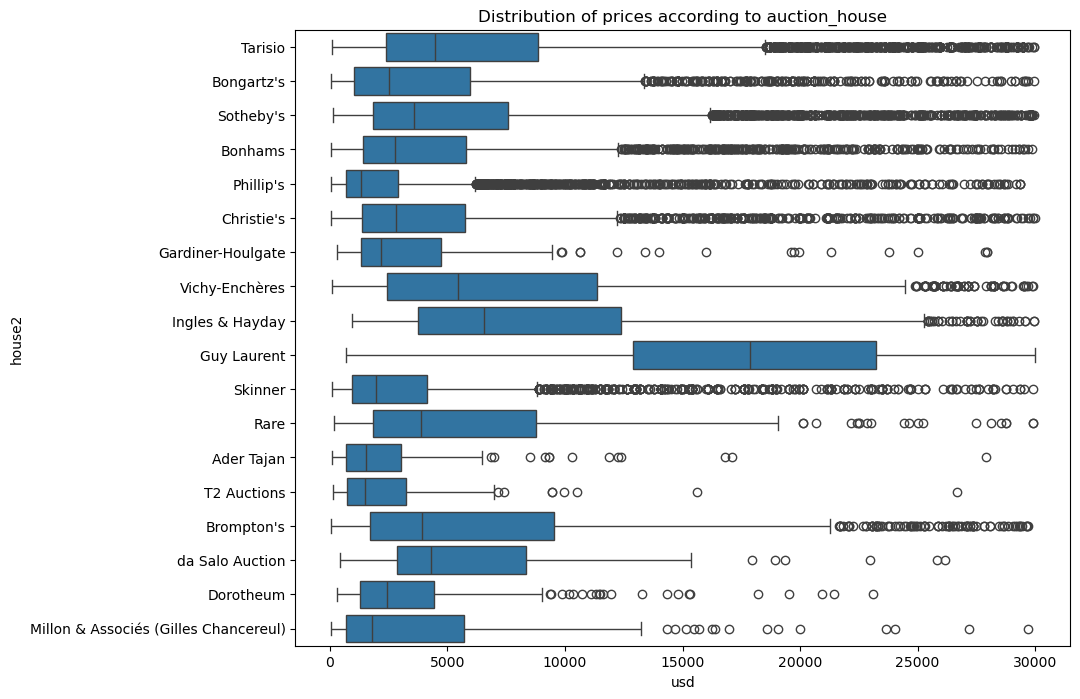

In [386]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit la taille de la figure pour que ce soit lisible
plt.figure(figsize=(10, 8))

# On passe 'house2' en paramètre 'y' au lieu de 'hue'
sns.boxplot(data=sales_moder, x='usd', y='house2')

plt.title('Distribution of prices according to auction_house')
plt.show()

One big house achieved incredible results, Guy Laurent. Skinner has a particularly heavy tail. The most represented houses - the highest on the graph - did not necessarily make the best results.

In [274]:
sales[sales['house2']=='Guy Laurent']

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency,maker_last_name,year,house2
62,1988,"Adam, Jean 'Grand'",Violin Bow,Mirecourt,Guy Laurent,"Dec 10, 2005",50,24324.0,13857.0,20640.0,eur,Adam,2005,Guy Laurent
69,1988,"Adam, Jean 'Grand'",Violin Bow,Mirecourt,Guy Laurent,"Jun 5, 2003",182,16485.0,9933.0,14000.0,eur,Adam,2003,Guy Laurent
70,1988,"Adam, Jean 'Grand'",Cello Bow,Mirecourt,Guy Laurent,"Jun 5, 2003",200,19429.0,11706.0,16500.0,eur,Adam,2003,Guy Laurent
73,1988,"Adam, Jean 'Grand'",Cello Bow,Mirecourt,Guy Laurent,"Dec 1, 2000",90,4859.0,3381.0,5563.0,NaN,Adam,2000,Guy Laurent
318,5,"Alberti, Ferdinando",Violin,Milan,Guy Laurent,"Dec 4, 2008",-,36346.0,24573.0,28800.0,eur,Alberti,2008,Guy Laurent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50904,760,"Tourte, Nicolas Léonard 'l'Ainé'",Violin Bow,Paris,Guy Laurent,"Nov 30, 1996",-,9390.0,5583.0,NaN,NaN,Tourte,1996,Guy Laurent
50905,760,"Tourte, Nicolas Léonard 'l'Ainé'",Violin Bow,Paris,Guy Laurent,"Jun 1, 1996",-,14134.0,9122.0,NaN,NaN,Tourte,1996,Guy Laurent
52225,2462,"Vangelisti, Pier (Pietro) Lorenzo",Violin,Florence,Guy Laurent,"Jun 5, 2008",-,36041.0,18423.0,23400.0,eur,Vangelisti,2008,Guy Laurent
54508,809,"Vuillaume, Jean-Baptiste",Violin,Paris,Guy Laurent,"Jun 5, 2008",-,168190.0,85973.0,109200.0,eur,Vuillaume,2008,Guy Laurent


<Axes: >

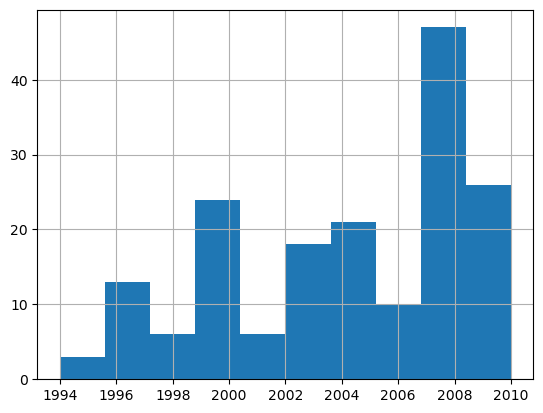

In [276]:
sales[sales['house2']=='Guy Laurent']['year'].hist()

Guy Laurent has 174 sales archived here, some of them feature particularly famous makers such as Jean Adam. it seems that it made sales from 1994 to 2010. In particular it didn't sell the last 15 years, where prices increased significantly, which makes the sensational prices particularly remarkable.

In [277]:
sales[sales['house2']=='Guy Laurent']['year'].describe()

count     174.000000
mean     2004.120690
std         4.289027
min      1994.000000
25%      2000.000000
50%      2005.000000
75%      2008.000000
max      2010.000000
Name: year, dtype: float64

In [272]:
sales['house2'].value_counts().index

Index(['Tarisio', 'Sotheby's', 'Phillip's', 'Christie's', 'Skinner', 'Bonhams',
       'Bongartz's', 'Vichy-Enchères', 'Brompton's', 'Ingles & Hayday', 'Rare',
       'Sotheby Parke Bernet', 'Millon & Associés (Gilles Chancereul)',
       'Puttick & Simpson', 'Dorotheum', 'Guy Laurent', 'Gardiner-Houlgate',
       'T2 Auctions', 'Ader Tajan', 'da Salo Auction'],
      dtype='object', name='house2')

## Makers

In [282]:
most_frequent_makers=sales['maker_name'].value_counts().index[:30]

In [285]:
def maker2(maker):
    return maker if maker in most_frequent_makers else 'Rare'

In [286]:
sales['maker2']=sales['maker_name'].apply(maker2)

In [302]:
sales_moder['maker2']=sales_moder['maker_name'].apply(maker2)

<Axes: xlabel='usd', ylabel='maker2'>

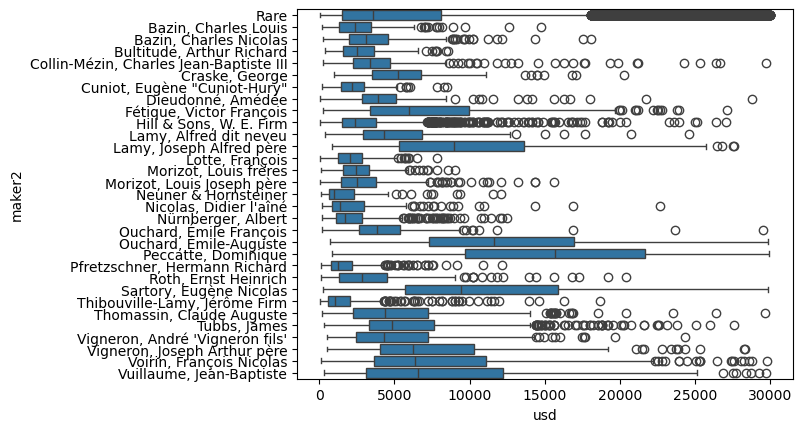

In [303]:
sns.boxplot(data=sales_moder,y='maker2',x='usd')

The graphic above shows that certain frequently sold makers tend to achieve better prices than average (among the recent, moderate sale, otherwise graphic illegible). One particularly valued maker is Dominique Peccatte. We also see that all the 30 most frequently sold makers, apart from Hill & Sons Firm (which again is not an individual maker but a firm), George Craske and three german makers, have French names. 

It is worth noting that four families have two frequently sold makers : Bazin, Lamy, Vigneron and Ouchard, with a father and a son. The Ouchard son is somehow much more valued on the market, showing that two members of a family can be very differently valued. Many of the most prolific makers do not show a better distribution, than distribution of the "rare" category.

In [298]:
salesAdam=sales_moder[sales_moder['maker_last_name']=='Adam']

<Axes: xlabel='usd'>

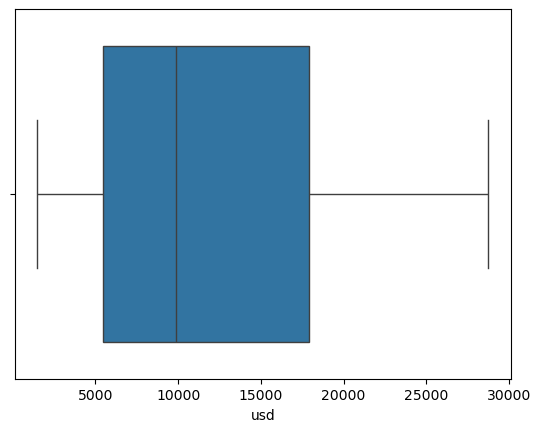

In [299]:
sns.boxplot(data=salesAdam,x='usd')

<Axes: xlabel='usd'>

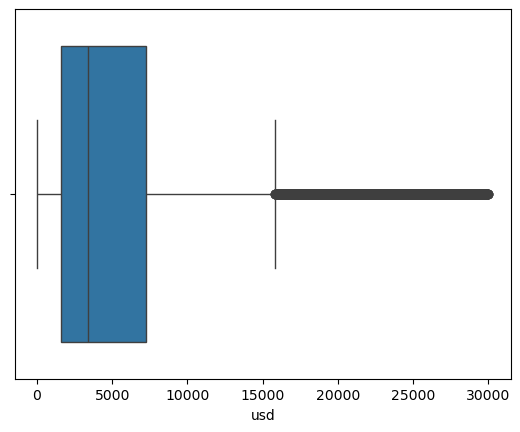

In [297]:
sns.boxplot(data=sales_moder,x='usd')

Certain makers that do not belong to the 30 most frequently sold ones, such as those of the Adam family, perform much better than average.

## Dates of makers

In [307]:
sum(maker_profiles.date.isna())

1499

1500 out 5000 maker_profiles have no dates, which is a problem in a bid to exploit the era a maker lives in to evaluate his work.

Let's have a look at these makers which have no date.

In [322]:
maker_profiles[maker_profiles['date'].isna()]

,maker_name,maker_id,role,date,info,maker_last_name
16,"Aerts, René & Marcel",15467,Violin maker,NaN,NaN,Aerts
18,"Aguzzi, Dario",15601,Violin maker,NaN,NaN,Aguzzi
30,"Albani, Michele",1676,Violin maker,NaN,NaN,Albani
33,"Alberini, Guido",15592,Violin maker,NaN,NaN,Alberini
34,"Albert, Ádám Karóly",15279,Violin maker,NaN,NaN,Albert
...,...,...,...,...,...,...
4935,"Zobboli, Bruno",840,Violin maker,NaN,NaN,Zobboli
4937,"Zoephel, Willy",3072,Violin maker,NaN,NaN,Zoephel
4941,"Zucker, Frantisek",15411,–,NaN,NaN,Zucker
4945,"Zurlini, Nicola",842,Violin maker,NaN,NaN,Zurlini


Those with no date all seem to have no info. And it is not an artefact of the scraping, the website genuinely gives no info about them.

In [319]:
ids_a_filtrer = maker_profiles.loc[maker_profiles['date'].isna(), 'maker_id'].unique()
sales_filtres = sales[sales['maker_id'].isin(ids_a_filtrer)]

In [326]:
sales_filtres.usd.describe()

count      6434.000000
mean       3383.281318
std        4966.797735
min          48.000000
25%         903.500000
50%        1955.000000
75%        4027.250000
max      171524.000000
Name: usd, dtype: float64

These makers, which represent almost one third of the makers' list, represent less than one eigth of the sales. But that's not quite negligible. Also they tend to sell significantly lower prices than the others.

In [327]:
sales.usd.describe()

count    5.716500e+04
mean     1.516633e+04
std      1.233990e+05
min      2.000000e+01
25%      1.548000e+03
50%      3.637000e+03
75%      9.442000e+03
max      1.582128e+07
Name: usd, dtype: float64

In [370]:
import re

def birth_cent(date_str):
    # On gère le cas où la date est nulle ou non définie
    if not isinstance(date_str, str) or date_str.lower() == 'nan':
        return np.nan
    
    # On cherche le premier groupe de 3 ou 4 chiffres (ex: 1750, 850)
    match = re.search(r'\d{3,4}', date_str)
    
    if match:
        annee = int(match.group())
        
        # Calcul du siècle : 1750 // 100 = 17 -> 17 + 1 = 18e siècle
        # Exception pour les années pile comme 1700 qui sont encore au XVIIe
        if annee % 100 == 0:
            siecle_num = annee // 100
        else:
            siecle_num = (annee // 100) + 1
            
        return str(siecle_num)
    
    return np.nan



In [371]:
maker_profiles['birth_cent']=maker_profiles['date'].apply(birth_cent)

In [372]:
maker_profiles['birth_cent'].value_counts()

birth_cent
19    1640
18     811
20     772
17     201
16      22
21       3
2        1
15       1
Name: count, dtype: int64

In [376]:
maker_profiles[maker_profiles['birth_cent']=='2']
#that's clearly a mistake, we'll make the century XVIIIth.

,maker_name,role,date,info,maker_last_name,birth_cent
maker_id,,,,,,
6205,"Ficker, Johann Gottlob II",Violin maker,178-1827,Johann Gottlob Ficker was the son and pupil of...,Ficker,2


In [379]:
maker_profiles.loc[maker_profiles['birth_cent']=='2','birth_cent']='18'


In [380]:
maker_profiles['birth_cent'].value_counts()

birth_cent
19    1640
18     812
20     772
17     201
16      22
21       3
15       1
Name: count, dtype: int64

In [381]:
def birth_cent_from_id(maker_id):
    return birth_cent(maker_profiles.loc[maker_id,'date'])

In [382]:
sales['maker_birth_cent']=sales['maker_id'].apply(birth_cent_from_id)

In [383]:
sales_moder['maker_birth_cent']=sales_moder['maker_id'].apply(birth_cent_from_id)

There is an evidence here that older centuries are more valued than newer. It's precisely because the box plot makes a mess when maker_birth_cent is numeric that I decided to make it string. Note that the makers of the XXIst and of the XVth century are not represented, because too few.

<Axes: xlabel='usd', ylabel='maker_birth_cent'>

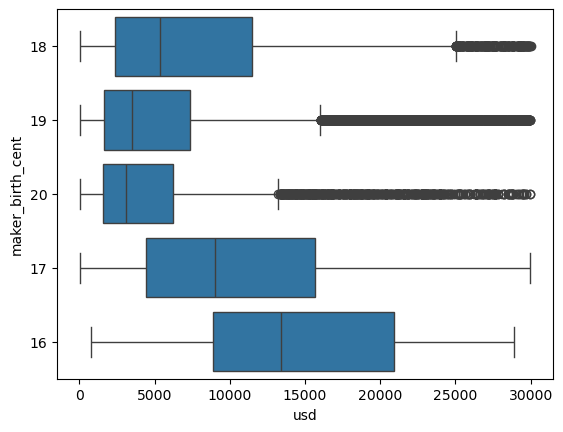

In [384]:
sns.boxplot(data=sales_moder,x='usd',y='maker_birth_cent')

In [387]:
sales_moder.to_csv("sales_moder.csv",index=False)

In [393]:
sales.to_csv("sales_engineered.csv",index=False)

In [391]:
sales_recent.to_csv("sales_recent.csv",index=False)

In [395]:
maker_profiles.to_csv("maker_profiles_engineered.csv",index=False)